# Surface Observation Quality Control

**Runnable companion to [`surface-obs-guide.md`](../surface-obs-guide.md) (§7 Quality Control).**

Raw station data contains gross errors, frozen sensors, and impossible values.
This notebook pulls **real ASOS observations**, maps them to the guide's QC
schema, and runs the standard checks from the guide:

- **Range check** — physically impossible values
- **Internal consistency** — e.g. dewpoint above temperature
- **Spike check** — implausible jumps between time steps
- **Persistence check** — a sensor stuck on one value

We deliberately inject a few errors into the clean record so you can see each
check fire.

**Station:** Jakarta `WIII`, 10–20 Jan 2024.

> Live data with committed cached fallback; see [`../../NOTEBOOKS.md`](../../NOTEBOOKS.md).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from meteo_examples import dataio

raw = dataio.iem_asos("WIII", "2024-01-10", "2024-01-20")
# Map ASOS column names to the guide's QC schema
df = pd.DataFrame({
    "datetime":      raw["valid"],
    "temp_c":        raw["tmpc"],
    "dewpoint_c":    raw["dwpc"],
    "rh_pct":        raw["relh"],
    "wind_speed_ms": raw["sknt"] * 0.514444,
    "wind_dir_deg":  raw["drct"],
    "slp_hpa":       raw["mslp"],
}).set_index("datetime").sort_index()
print(f"{len(df)} reports from {df.index.min()} to {df.index.max()}")
df.head()

481 reports from 2024-01-10 00:00:00 to 2024-01-19 23:30:00


,temp_c,dewpoint_c,rh_pct,wind_speed_ms,wind_dir_deg,slp_hpa
datetime,,,,,,
2024-01-10 00:00:00,27.0,26.0,94.27,1.543332,200.0,NaN
2024-01-10 00:30:00,28.0,28.0,100.00,1.543332,230.0,NaN
2024-01-10 01:00:00,29.0,27.0,88.98,3.086664,240.0,NaN
2024-01-10 01:30:00,29.0,27.0,88.98,3.086664,240.0,NaN
2024-01-10 02:00:00,30.0,26.0,79.18,3.601108,230.0,NaN


## 1 · Inject a few deliberate errors

So the checks have something to catch in an otherwise clean record.

In [2]:
df.iloc[20, df.columns.get_loc("temp_c")]       = 85.0    # impossible (range)
df.iloc[50, df.columns.get_loc("dewpoint_c")]   = df.iloc[50]["temp_c"] + 6  # Td > T (consistency)
df.iloc[80, df.columns.get_loc("temp_c")]       = df.iloc[79]["temp_c"] + 25 # spike
df.iloc[120:130, df.columns.get_loc("slp_hpa")] = 1011.0  # stuck sensor (persistence)
print("injected: range(20), consistency(50), spike(80), persistence(120-129)")

injected: range(20), consistency(50), spike(80), persistence(120-129)


## 2 · QC functions (from the guide)

In [3]:
QC_GOOD, QC_SUSPECT, QC_BAD, QC_MISSING = 0, 1, 2, 9

RANGE_LIMITS = {
    "temp_c": (-90, 60), "dewpoint_c": (-90, 40), "slp_hpa": (870, 1084),
    "wind_speed_ms": (0, 100), "wind_dir_deg": (0, 360), "rh_pct": (0, 100),
}
SPIKE_THRESHOLDS = {"temp_c": 10.0, "dewpoint_c": 10.0, "slp_hpa": 6.0, "wind_speed_ms": 20.0}

def init_qc_flags(df, variables):
    for v in variables:
        df[f"{v}_qc"] = QC_GOOD
        df.loc[df[v].isna(), f"{v}_qc"] = QC_MISSING
    return df

def range_check(df, limits=RANGE_LIMITS):
    for v, (lo, hi) in limits.items():
        if v in df:
            df.loc[(df[v] < lo) | (df[v] > hi), f"{v}_qc"] = QC_BAD
    return df

def consistency_check(df):
    m = df["dewpoint_c"] > df["temp_c"] + 0.5
    df.loc[m, "dewpoint_c_qc"] = QC_BAD
    return df

def spike_check(df, var, max_change):
    rate = df[var].diff().abs() / (df.index.to_series().diff().dt.total_seconds() / 3600).replace(0, np.nan)
    df.loc[rate > max_change, f"{var}_qc"] = np.maximum(df.loc[rate > max_change, f"{var}_qc"], QC_SUSPECT)
    return df

def persistence_check(df, var, max_repeats=6):
    groups = df[var].ne(df[var].shift()).cumsum()
    counts = groups.map(groups.value_counts())
    m = (counts >= max_repeats) & df[var].notna()
    df.loc[m, f"{var}_qc"] = np.maximum(df.loc[m, f"{var}_qc"], QC_SUSPECT)
    return df

## 3 · Run the pipeline

In [4]:
variables = ["temp_c", "dewpoint_c", "slp_hpa", "wind_speed_ms", "wind_dir_deg"]
df = init_qc_flags(df, variables)
df = range_check(df)
df = consistency_check(df)
for v, thr in SPIKE_THRESHOLDS.items():
    if v in variables:
        df = spike_check(df, v, thr)
df = persistence_check(df, "slp_hpa")

flag_names = {QC_GOOD: "good", QC_SUSPECT: "suspect", QC_BAD: "bad", QC_MISSING: "missing"}
summary = pd.DataFrame({v: df[f"{v}_qc"].map(flag_names).value_counts() for v in variables}).fillna(0).astype(int)
summary

,temp_c,dewpoint_c,slp_hpa,wind_speed_ms,wind_dir_deg
bad,1,1,0,0,0
good,474,476,0,481,461
missing,3,3,471,0,20
suspect,3,1,10,0,0


In [5]:
# Show exactly which reports were flagged bad/suspect
flagged = df[(df["temp_c_qc"] > 0) | (df["dewpoint_c_qc"] > 0) | (df["slp_hpa_qc"] > 0)]
flagged[["temp_c", "temp_c_qc", "dewpoint_c", "dewpoint_c_qc", "slp_hpa", "slp_hpa_qc"]].head(15)

,temp_c,temp_c_qc,dewpoint_c,dewpoint_c_qc,slp_hpa,slp_hpa_qc
datetime,,,,,,
2024-01-10 00:00:00,27.0,0,26.0,0,NaN,9
2024-01-10 00:30:00,28.0,0,28.0,0,NaN,9
2024-01-10 01:00:00,29.0,0,27.0,0,NaN,9
2024-01-10 01:30:00,29.0,0,27.0,0,NaN,9
2024-01-10 02:00:00,30.0,0,26.0,0,NaN,9
2024-01-10 02:30:00,31.0,0,26.0,0,NaN,9
2024-01-10 03:00:00,31.0,0,25.0,0,NaN,9
2024-01-10 03:30:00,31.0,0,25.0,0,NaN,9
2024-01-10 04:00:00,32.0,0,25.0,0,NaN,9


## 4 · Visualise the flags on the temperature trace

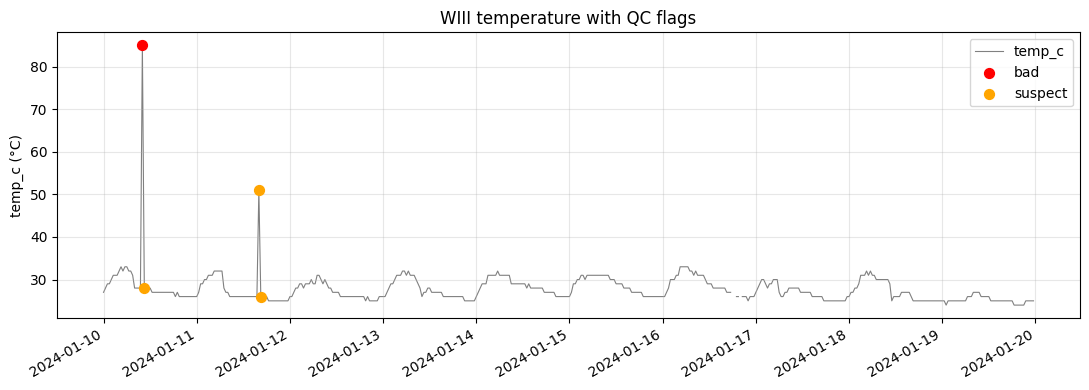

In [6]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(df.index, df["temp_c"], "-", lw=0.8, color="gray", label="temp_c", zorder=1)
for flag, color, lab in [(QC_BAD, "red", "bad"), (QC_SUSPECT, "orange", "suspect")]:
    mask = df["temp_c_qc"] == flag
    ax.scatter(df.index[mask], df["temp_c"][mask], c=color, s=50, zorder=3, label=lab)
ax.set(ylabel="temp_c (°C)", title="WIII temperature with QC flags")
ax.legend(); ax.grid(alpha=0.3); fig.autofmt_xdate(); plt.tight_layout()

The range error and the spike are caught immediately. In operations you
would also run the **spatial buddy check** (`buddy_check` in the guide) across a
station network — it needs multiple stations at one time, so it isn't shown here.

---
### Next steps
- Keep only `*_qc == 0` rows before feeding obs into verification
  ([`../../verification/notebooks/01_point_verification.ipynb`](../../verification/notebooks/01_point_verification.ipynb)).
- Tune `RANGE_LIMITS`/`SPIKE_THRESHOLDS` for your climate (tropical vs polar).
- See the guide for the MET-ASCII export (`obs_to_met_ascii`) to feed Point-Stat.